In [1]:
from langgraph.graph import StateGraph, START, END

from afm_lib.schemas.recipe import load_recipe
from afm_lib.states.lib_experiment_state import LibExperimentState
from afm_lib.nodes.init_run_node import init_run_node
from afm_lib.nodes.preflight_node import preflight_node
from afm_lib.nodes.calibrate_frame_node import calibrate_frame_node
from afm_lib.nodes.sync_status_node import sync_status_node

print("imports ok")

imports ok


In [2]:
recipe = load_recipe("../recipes/smoke_2site.yaml")
print(recipe.name, "-", len(recipe.sites), "sites")
for s in recipe.sites:
    print(f"  {s.label}: ({s.x_stage_m*1e3:+.3f}, {s.y_stage_m*1e3:+.3f}) mm")
print("per_site:", recipe.per_site[0].points_m, recipe.per_site[0].loop_settings)

smoke_2site - 2 sites
  S0: (+0.000, +0.000) mm
  S1: (+1.000, +0.000) mm
per_site: [(0.0, 0.0)] v_dc_max_v=3.0 frequency_hz=0.5 var0_phase=0.0 var1_pulsetime_s=0.01 n_cycles=1


In [3]:
from afm_lib.instrument.session import call

raw = await call("pfm_get_experiment_status")
print("stage_x_m:", raw.get("stage_x_m"))
print("stage_y_m:", raw.get("stage_y_m"))
print("feedback_on:", raw.get("feedback_on"))
print("directory:", raw.get("directory"))
print("warnings:", raw.get("warnings"))

stage_x_m: 0.022655156
stage_y_m: 0.0044568749
feedback_on: False
directory: C:\Users\Asylum User\Documents\Asylum Research Data\260825
warnings: []


compiled


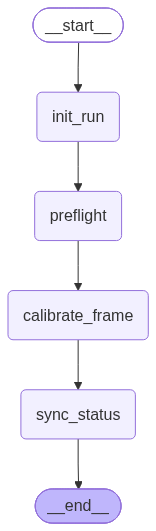

In [4]:
g = StateGraph(LibExperimentState)
g.add_node("init_run",        init_run_node)
g.add_node("preflight",       preflight_node)
g.add_node("calibrate_frame", calibrate_frame_node)
g.add_node("sync_status",     sync_status_node)

g.add_edge(START,             "init_run")
g.add_edge("init_run",        "preflight")
g.add_edge("preflight",       "calibrate_frame")
g.add_edge("calibrate_frame", "sync_status")
g.add_edge("sync_status",     END)

prologue = g.compile()
print("compiled")
prologue

In [5]:
out = await prologue.ainvoke({"recipe": recipe})
print("\ndone")

[init_run] smoke_2site: 2 sites x 1 points = 2 loops -> C:\Users\Asylum User\Documents\GitHub\AFM_Combinatorial_Libraries\runs\20260827_090426_smoke_2site
[preflight] stage (+22.655, +4.457) mm | dir 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260825' | feedback False | frame 1.0 um @ 256 px | f_DART 364.3 kHz | V_ac 0.40000001 V
[calibrate] offset (-17.972, +15.548) um | sens 9.2640e-06 / 9.9032e-06 m/V

done


In [7]:
print("session_info:      ", out["session_info"])
print()
print("scanner_calibs:    ", out["scanner_calibrations"])
print()
live = out["instrument_state"]
print("stage_position:    ", live.stage_position)
print("probe_position:    ", live.probe_position)      # populated now, post-calibration
print("scan_settings:     ", live.scan_settings)
print()
print("sites:             ", [(s["label"], s["status"]) for s in out["sites"]])
print("site_index:        ", out["site_index"])

session_info:       {'run_dir': 'C:\\Users\\Asylum User\\Documents\\GitHub\\AFM_Combinatorial_Libraries\\runs\\20260827_090426_smoke_2site', 'started_ts': 1787835867.1454587, 'instrument_directory': 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260825'}

scanner_calibs:     x_scanner_offset_m=-1.7972080222395838e-05 y_scanner_offset_m=1.5547959992315857e-05 x_lvdt_sens_m_per_v=9.2639584e-06 y_lvdt_sens_m_per_v=9.9031586e-06

stage_position:     x_stage_m=0.022655156 y_stage_m=0.0044568749
probe_position:     x_m=0.0 y_m=0.0
scan_settings:      x_scan_center_m=0.0 y_scan_center_m=0.0 scan_size_m=1e-06 pixels=256 scan_rate_hz=1.0016025

sites:              [('S0', 'pending'), ('S1', 'pending')]
site_index:         -1


In [8]:
cal_before = out["scanner_calibrations"]

await call("pfm_move_stage", {"x_stage_m": raw["stage_x_m"] + 1e-3,
                              "y_stage_m": raw["stage_y_m"],
                              "approach_after": True})

cal_after = (await calibrate_frame_node({}))["scanner_calibrations"]

dx = (cal_after.x_scanner_offset_m - cal_before.x_scanner_offset_m) * 1e9
dy = (cal_after.y_scanner_offset_m - cal_before.y_scanner_offset_m) * 1e9
print(f"offset drift after a 1 mm stage move: {dx:+.1f}, {dy:+.1f} nm")

[calibrate] offset (-17.972, +15.548) um | sens 9.2640e-06 / 9.9032e-06 m/V
offset drift after a 1 mm stage move: +0.0, +0.0 nm
